<a href="https://colab.research.google.com/github/thanvi675/fictional-tribble/blob/main/EDA_experinment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Records
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compr

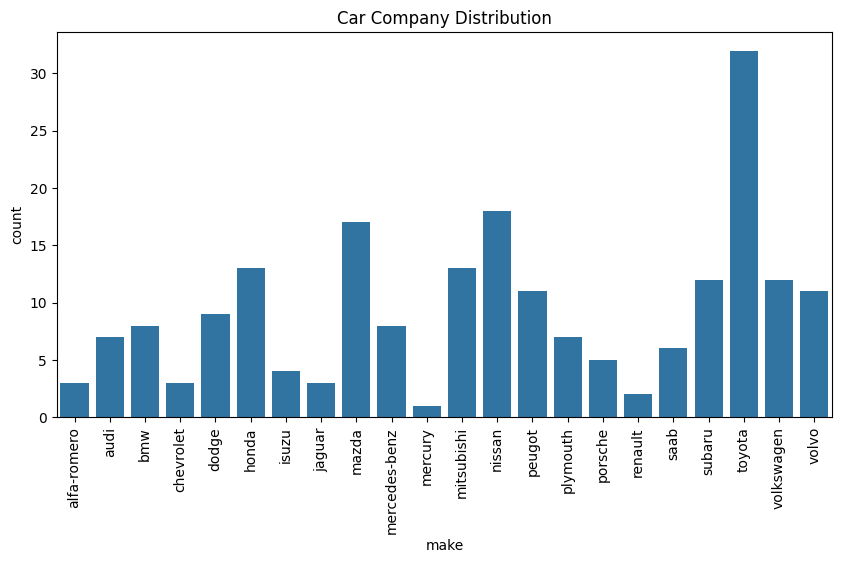

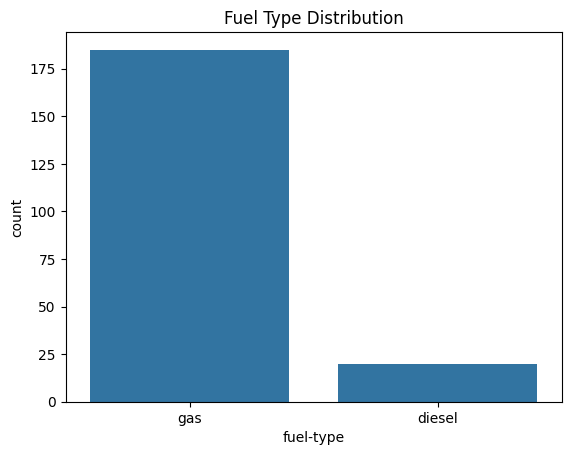

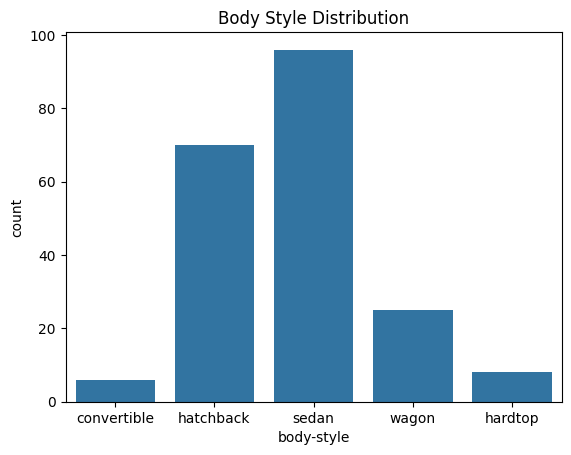

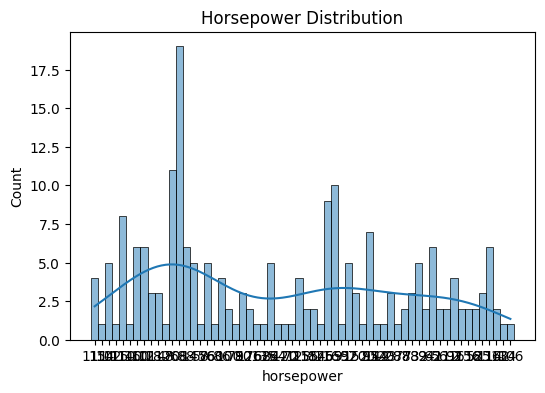

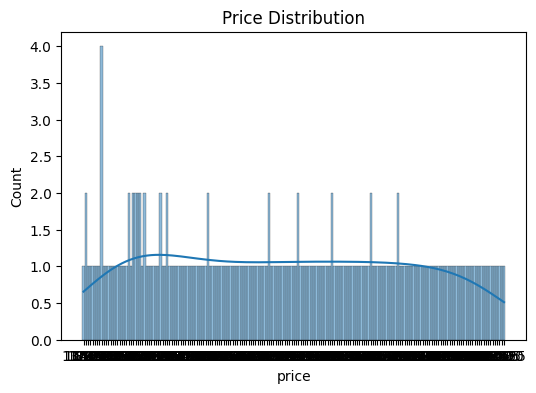

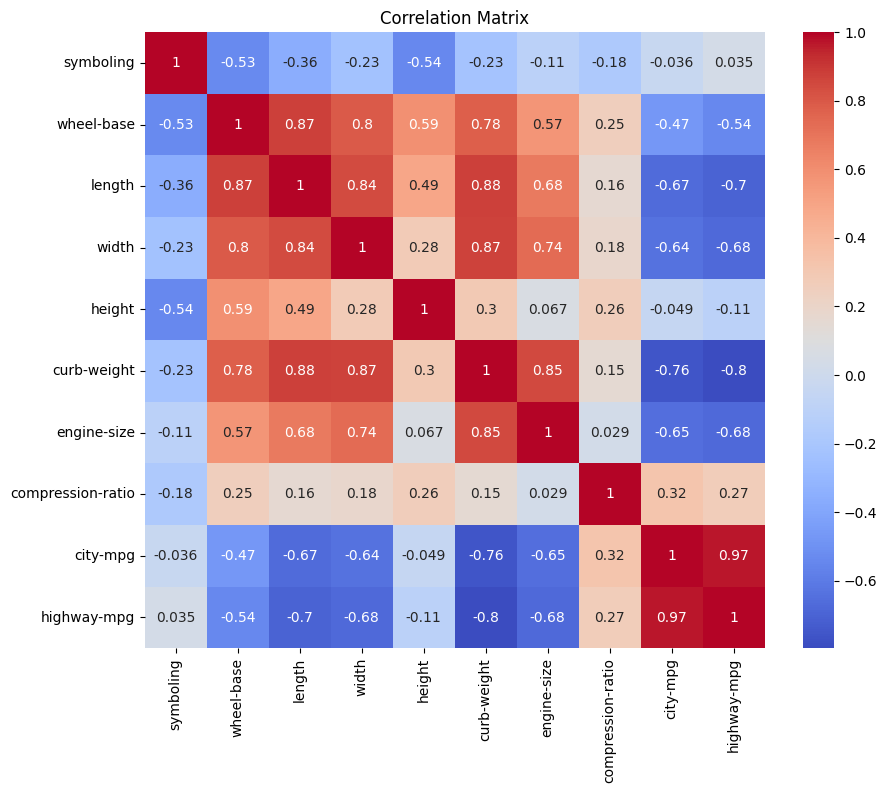


Numeric Attributes
Index(['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight',
       'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg'],
      dtype='object')

Nominal Attributes
['make', 'fuel-type', 'body-style']

Binary Attributes
['fuel-type']

Nominal Attribute Dissimilarity
Make vs Fuel-Type = 1.0

Euclidean Distance
3005.0

Manhattan Distance
3005.0

Minkowski Distance
3004.9999999999986

Cosine Dissimilarity
1.1218697986148385e-06


In [6]:
# ==========================================
# AUTOMOBILE DATASET ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# (a) Read the Dataset
# ==========================================

df = pd.read_csv("Automobile_data.csv")

print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

# Car Company Count
plt.figure(figsize=(10,5))
sns.countplot(x='make', data=df)
plt.xticks(rotation=90)
plt.title("Car Company Distribution")
plt.show()

# Fuel Type Count
sns.countplot(x='fuel-type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

# Body Style Count
sns.countplot(x='body-style', data=df)
plt.title("Body Style Distribution")
plt.show()

# Horsepower Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['horsepower'], bins=20, kde=True)
plt.title("Horsepower Distribution")
plt.show()

# Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

# ==========================================
# (b) Identify Attributes
# ==========================================

print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64','float64']).columns
print(numeric)

print("\nNominal Attributes")
nominal = ['make', 'fuel-type', 'body-style']
print(nominal)

print("\nBinary Attributes")
binary = ['fuel-type']
print(binary)

# ==========================================
# (c) Dissimilarity for Nominal Attributes
# Simple Matching Dissimilarity
# ==========================================

make = df['make']
fuel = df['fuel-type']

count = 0
total = 0

for m, f in zip(make, fuel):

    if pd.isna(m) or pd.isna(f):
        continue

    total += 1

    if m != f:
        count += 1

dissimilarity = count / total

print("\nNominal Attribute Dissimilarity")
print("Make vs Fuel-Type =", dissimilarity)

# ==========================================
# (d) Numeric Attribute Dissimilarity
# Euclidean Distance
# ==========================================

# Convert columns to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Remove rows with missing values
temp = df[['horsepower', 'price']].dropna()
hp1 = temp.iloc[0]['horsepower']
price1 = temp.iloc[0]['price']

hp2 = temp.iloc[1]['horsepower']
price2 = temp.iloc[1]['price']

# Euclidean Distance
distance = np.sqrt((hp1 - hp2)**2 + (price1 - price2)**2)

print("\nEuclidean Distance")
print(distance)

# Manhattan Distance
manhattan = abs(hp1 - hp2) + abs(price1 - price2)

print("\nManhattan Distance")
print(manhattan)

# Minkowski Distance (p=3)
minkowski = ((abs(hp1 - hp2)**3) + (abs(price1 - price2)**3))**(1/3)

print("\nMinkowski Distance")
print(minkowski)

# Cosine Dissimilarity
A = np.array([hp1, price1])
B = np.array([hp2, price2])

cosine_similarity = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
cosine_dissimilarity = 1 - cosine_similarity

print("\nCosine Dissimilarity")
print(cosine_dissimilarity)